In [1]:
import argparse
import csv
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import random
import scanpy as sc
from torch.utils.data import DataLoader
from model.dataset import BagsDataset, custom_collate_fn
from model.model import MIL

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [42]:
def load_all_genes(reference_gene_file):
    all_genes = []
    with open(reference_gene_file, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            all_genes.append(row['Gene'])
    return all_genes

all_genes = load_all_genes('data/human.csv')

In [43]:
model_path = 'test/all_cpu_revised_human_0.1_10000_5/final_model.pth'
all_genes_df = pd.read_csv('data/human.csv')  # Replace with your reference gene file path
all_genes = all_genes_df['Gene'].tolist()

# Initialize the model
model = MIL(all_genes).to(device)

In [44]:
model.load_state_dict(torch.load(model_path, map_location=device))


<All keys matched successfully>

In [45]:
model.state_dict()

OrderedDict([('alpha', tensor(2.0154)),
             ('beta', tensor(-3.4677)),
             ('distance.a', tensor(0.9261)),
             ('gene_expression.b', tensor(0.6571)),
             ('immunogenicity.ig',
              tensor([-1.0000, -0.7577, -0.3132,  ..., -1.0000, -1.0000, -1.0000]))])

In [30]:
common_genes = pd.read_csv('simulate_data/common_genes_human_antigen.csv')['Gene'].tolist()

In [31]:
genes_to_modify = common_genes

len(genes_to_modify)

7451

In [32]:

all_gene_indices = list(range(len(all_genes)))

len(all_gene_indices)

27200

In [33]:

indices_to_modify = [model.immunogenicity.gene_to_index[gene] for gene in genes_to_modify]
len(indices_to_modify)

7451

In [34]:


indices_remaining = list(set(all_gene_indices) - set(indices_to_modify))
len(indices_remaining)

19749

In [35]:

for idx in indices_to_modify:
    original_ig = model.immunogenicity.ig.data[idx].item()
    new_score = random.uniform(1, 10)
    model.immunogenicity.ig.data[idx] = new_score



In [36]:

for idx in indices_remaining:
    original_ig = model.immunogenicity.ig.data[idx].item()
    new_score = random.uniform(-3, -1)
    model.immunogenicity.ig.data[idx] = new_score


In [37]:
#model.gene_expression.b = torch.nn.Parameter(torch.tensor(-0.5))

In [38]:
model.state_dict()

OrderedDict([('alpha', tensor(2.0154)),
             ('beta', tensor(-3.4677)),
             ('distance.a', tensor(0.9261)),
             ('gene_expression.b', tensor(0.6571)),
             ('immunogenicity.ig',
              tensor([-2.4758,  8.9290, -1.7020,  ..., -2.0210, -2.7098, -2.3006]))])

In [46]:
torch.save(model.state_dict(), 'simulate_data/simulate_data.pth')

In [47]:
ig_scores = []
for gene, idx in model.immunogenicity.gene_to_index.items():
    ig_score = torch.sigmoid(model.immunogenicity.ig.data[idx]).item()
    ig_scores.append({'Gene': gene, 'IG Score': ig_score})

ig_df = pd.DataFrame(ig_scores)
ig_df.to_csv('simulate_data/ig_scores.csv', index=False)

In [48]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from model.dataset import BagsDataset, custom_collate_fn


In [49]:

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [50]:

# Load the list of all genes used during training
all_genes_df = pd.read_csv('data/human.csv')  # Replace with your reference gene file path
all_genes = all_genes_df['Gene'].tolist()


In [51]:

# Initialize the model and load parameters
model = MIL(all_genes).to(device)
model.load_state_dict(torch.load('simulate_data/simulate_data.pth'))
model.state_dict()


OrderedDict([('alpha', tensor(2.0154)),
             ('beta', tensor(-3.4677)),
             ('distance.a', tensor(0.9261)),
             ('gene_expression.b', tensor(0.6571)),
             ('immunogenicity.ig',
              tensor([-1.0000, -0.7577, -0.3132,  ..., -1.0000, -1.0000, -1.0000]))])

In [56]:

# Load the prediction dataset
adata = sc.read('/project/DPDS/Wang_lab/shared/spatial_TCR/data/train_validate/Visium/HumanOvarianCancer/T_cell.h5ad')
prediction_dataset = BagsDataset(adata, immune_cell='tcell', radius=300, n_genes=500, resolution='low')
prediction_dataloader = torch.utils.data.DataLoader(prediction_dataset, batch_size=1, collate_fn=custom_collate_fn)
adata.obs['T_pred'] = np.nan


Tumor cells shape after filtering: (1226, 17943)
Selecting top 500 genes based on mean expression
Top 500 genes: Index(['IGHM', 'IGLC1', 'IGKC', 'JCHAIN', 'B2M', 'TMSB4X', 'UBC', 'UBA52',
       'ACTB', 'FTL',
       ...
       'QKI', 'SGPL1', 'SLC38A2', 'YWHAQ', 'GBP5', 'CTNNB1', 'PTGS1', 'CLTC',
       'HP1BP3', 'DDIT4'],
      dtype='object', length=500)
Percentile value: 4.037618160247803
adata.obs[T] after binarization: AAACAAGTATCTCCCA-1    0
AAACAATCTACTAGCA-1    0
AAACACCAATAACTGC-1    1
AAACAGAGCGACTCCT-1    1
AAACAGCTTTCAGAAG-1    0
Name: T, dtype: int64
Preprocessed data: (3455, 500)


Creating Bags with radius 300: 100%|█████████████████████████| 3455/3455 [00:00<00:00, 21043.63it/s]

Total bags created: 1226
Average instances per bag: 10


In [57]:
with torch.no_grad():
    for distances, gene_expressions, labels, core_idxs, gene_names, cell_ids in prediction_dataloader:
        distances = [d.to(device) for d in distances]
        gene_expressions = [g.to(device) for g in gene_expressions]
        output = model(distances, gene_expressions, list(gene_names[0]))
        print(output)
        prediction = output.cpu().item()
        cell_id = cell_ids[0]

        # Store the prediction in 'adata.obs' using the 'cell_id'
        adata.obs.loc[cell_id, 'T_pred'] = prediction

tensor([0.2178])
tensor([0.0927])
tensor([0.2269])
tensor([0.2599])
tensor([0.2293])
tensor([0.2400])
tensor([0.1460])
tensor([0.1198])
tensor([0.3874])
tensor([0.2410])
tensor([0.5536])
tensor([0.1260])
tensor([0.4033])
tensor([0.3362])
tensor([0.3680])
tensor([0.1366])
tensor([0.1299])
tensor([0.0543])
tensor([0.1853])
tensor([0.3218])
tensor([0.0832])
tensor([0.2112])
tensor([0.1516])
tensor([0.0629])
tensor([0.2302])
tensor([0.6257])
tensor([0.2182])
tensor([0.1252])
tensor([0.1186])
tensor([0.1376])
tensor([0.3106])
tensor([0.2101])
tensor([0.2399])
tensor([0.2273])
tensor([0.1156])
tensor([0.1311])
tensor([0.2396])
tensor([0.2222])
tensor([0.3459])
tensor([0.1780])
tensor([0.1101])
tensor([0.2820])
tensor([0.2717])
tensor([0.2451])
tensor([0.2272])
tensor([0.1014])
tensor([0.2197])
tensor([0.1710])
tensor([0.3343])
tensor([0.2179])
tensor([0.0646])
tensor([0.2265])
tensor([0.0792])
tensor([0.1445])
tensor([0.1778])
tensor([0.2551])
tensor([0.4796])
tensor([0.1023])
tensor([0.1259

In [58]:
adata.obs['T_pred'].nunique()

1226

In [59]:
adata.obs

,n_genes,leiden,X,Y,T,cell_type,T_pred
AAACAAGTATCTCCCA-1,6534,1,5000,10200,0.740351,0,NaN
AAACAATCTACTAGCA-1,6269,10,300,4300,3.062929,0,NaN
AAACACCAATAACTGC-1,8812,8,5900,1900,4.386195,0,NaN
AAACAGAGCGACTCCT-1,7646,6,1400,9400,4.523868,1,0.217823
AAACAGCTTTCAGAAG-1,8470,2,4300,900,3.626352,1,0.092748
...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,9024,9,3100,7700,5.586387,1,0.163211
TTGTTTCACATCCAGG-1,6143,7,5800,4200,4.514490,0,NaN
TTGTTTCATTAGTCTA-1,6542,8,6000,3000,5.475519,0,NaN
TTGTTTCCATACAACT-1,9902,2,4500,2700,2.870928,1,0.154786


In [60]:
adata.obs.drop(columns=['T'], inplace=True, errors='ignore')

In [61]:
adata.obs['T'] = adata.obs['T_pred']

In [62]:
adata.obs['T'].fillna(0, inplace=True)

/tmp/ipykernel_6759/3824868176.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs['T'].fillna(0, inplace=True)


In [63]:
adata.obs

,n_genes,leiden,X,Y,cell_type,T_pred,T
AAACAAGTATCTCCCA-1,6534,1,5000,10200,0,NaN,0.000000
AAACAATCTACTAGCA-1,6269,10,300,4300,0,NaN,0.000000
AAACACCAATAACTGC-1,8812,8,5900,1900,0,NaN,0.000000
AAACAGAGCGACTCCT-1,7646,6,1400,9400,1,0.217823,0.217823
AAACAGCTTTCAGAAG-1,8470,2,4300,900,1,0.092748,0.092748
...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,9024,9,3100,7700,1,0.163211,0.163211
TTGTTTCACATCCAGG-1,6143,7,5800,4200,0,NaN,0.000000
TTGTTTCATTAGTCTA-1,6542,8,6000,3000,0,NaN,0.000000
TTGTTTCCATACAACT-1,9902,2,4500,2700,1,0.154786,0.154786


In [64]:
adata.obs['T'].unique() 

array([0.        , 0.21782333, 0.092748  , ..., 0.2008127 , 0.16321145,
       0.15478593])

In [65]:
adata.obs

,n_genes,leiden,X,Y,cell_type,T_pred,T
AAACAAGTATCTCCCA-1,6534,1,5000,10200,0,NaN,0.000000
AAACAATCTACTAGCA-1,6269,10,300,4300,0,NaN,0.000000
AAACACCAATAACTGC-1,8812,8,5900,1900,0,NaN,0.000000
AAACAGAGCGACTCCT-1,7646,6,1400,9400,1,0.217823,0.217823
AAACAGCTTTCAGAAG-1,8470,2,4300,900,1,0.092748,0.092748
...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,9024,9,3100,7700,1,0.163211,0.163211
TTGTTTCACATCCAGG-1,6143,7,5800,4200,0,NaN,0.000000
TTGTTTCATTAGTCTA-1,6542,8,6000,3000,0,NaN,0.000000
TTGTTTCCATACAACT-1,9902,2,4500,2700,1,0.154786,0.154786


In [66]:
adata.write('simulate_data/simulate_data/HumanOvarianCancer.h5ad')

In [67]:
model.state_dict()

OrderedDict([('alpha', tensor(2.0154)),
             ('beta', tensor(-3.4677)),
             ('distance.a', tensor(0.9261)),
             ('gene_expression.b', tensor(0.6571)),
             ('immunogenicity.ig',
              tensor([-1.0000, -0.7577, -0.3132,  ..., -1.0000, -1.0000, -1.0000]))])

In [68]:
expression_values = adata.X.data

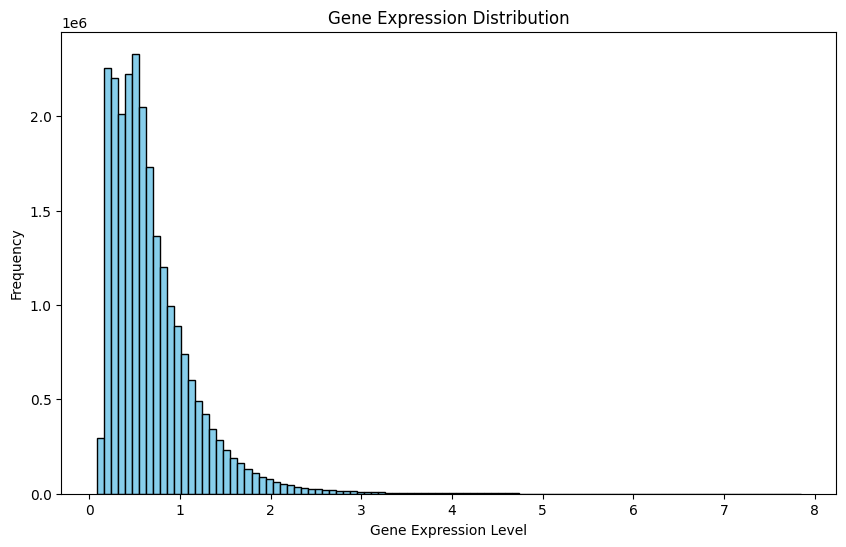

In [70]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(expression_values, bins=100, color='skyblue', edgecolor='black')
plt.xlabel('Gene Expression Level')
plt.ylabel('Frequency')
plt.title('Gene Expression Distribution')
plt.savefig('simulate_data/simulate_data/HumanOvarianCancer.png')
plt.show()


